# Лабораторна робота 2 — Проста лінійна регресія (аналітичний розв'язок)


**Набір даних:** `kc_house_data.csv`  
**Обмеження:** scikit-learn-регресія **не дозволена** для базових завдань.

## Налаштування

In [1]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib --quiet


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%matplotlib inline


## Теоретичне підґрунтя

Для однієї вхідної ознаки **x** та виходу **y** аналітичний розв'язок МНК:
```
slope     = ( Σ(xᵢ·yᵢ) − n·x̄·ȳ )  /  ( Σ(xᵢ²) − n·x̄² )
intercept = ȳ − slope · x̄
```
Сума квадратів залишків (RSS):
```
RSS = Σ ( yᵢ − (intercept + slope·xᵢ) )²
```

---
## Завдання 1 — Підготовка даних

Завантажте `kc_house_data.csv`. Розбийте на **навчальну (20 %) та тестову (80 %)** вибірки з `random_state=0`.

In [5]:
sales = pd.read_csv('../kc_house_data.csv')
train_data, test_data = train_test_split(sales, test_size=0.8, random_state=0)
print(f'Навчальна: {len(train_data)} рядків  |  Тестова: {len(test_data)} рядків')


Навчальна: 4322 рядків  |  Тестова: 17291 рядків


---
## Завдання 2 — Реалізація `simple_linear_regression()`

Завершіть функцію, використовуючи **лише NumPy** (без sklearn, без циклів по рядках).

In [27]:
def simple_linear_regression(input_feature, output):
    """
    Обчислює slope та intercept МНК для однієї ознаки.

    Параметри
    ----------
    input_feature : array-like, shape (n,)
    output        : array-like, shape (n,)

    Повертає
    -------
    intercept, slope : float, float
    """
    input_feature = np.array(input_feature, dtype=float)
    output        = np.array(output, dtype=float)
    n = len(input_feature)

    x = np.array(input_feature, dtype=float)
    y = np.array(output, dtype=float)
    
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    sum_xy = np.sum(x * y)
    sum_x_squared = np.sum(x ** 2)
    
    numerator = sum_xy - (n * x_mean * y_mean)
    denominator = sum_x_squared - (n * (x_mean ** 2))

    slope = numerator / denominator
    intercept = y_mean - slope * x_mean

    return intercept, slope


### Перевірка — обидва значення нижче мають дорівнювати **1.0**

In [28]:
test_feature = np.arange(5, dtype=float)
test_output  = 1.0 + 1.0 * test_feature
test_intercept, test_slope = simple_linear_regression(test_feature, test_output)
print(f'Intercept: {test_intercept:.4f}  (очікується 1.0)')
print(f'Slope    : {test_slope:.4f}  (очікується 1.0)')


Intercept: 1.0000  (очікується 1.0)
Slope    : 1.0000  (очікується 1.0)


### Навчання на `sqft_living`

In [29]:
sqft_intercept, sqft_slope = simple_linear_regression(
    train_data['sqft_living'], train_data['price']
)
print(f'Вільний член: {sqft_intercept:.2f}')
print(f'Нахил: {sqft_slope:.4f}')


Вільний член: -29748.29
Нахил: 273.5299


---
## Завдання 3 — Передбачення та RSS

**а)** Реалізуйте `get_regression_predictions(input_feature, intercept, slope)` — повертає масив NumPy передбачених значень.  
**б)** Реалізуйте `get_residual_sum_of_squares(input_feature, output, intercept, slope)` — обчислює RSS.  
**в)** Перевірте обидві функції, потім вкажіть RSS на навчальній і тестовій вибірках та дайте відповідь на питання нижче.

In [30]:
def get_regression_predictions(input_feature, intercept, slope):
    """Повертає масив передбачених значень."""
    input_feature = np.array(input_feature, dtype=float)
    predictions = intercept + slope * input_feature
    return predictions


In [31]:
def get_residual_sum_of_squares(input_feature, output, intercept, slope):
    """Повертає RSS (скаляр). RSS = Σ ( yᵢ − (intercept + slope·xᵢ) )²"""
    input_feature = np.array(input_feature, dtype=float)
    output = np.array(output, dtype=float)

    predictions = intercept + slope * input_feature
    residuals = output - predictions
    rss = np.sum(residuals ** 2)

    return rss


### Перевірка — RSS на тестових вхідних даних має бути **0.0**

In [32]:
rss_check = get_residual_sum_of_squares(
    test_feature, test_output, test_intercept, test_slope
)
print(f'RSS на тестових вхідних даних: {rss_check:.2f}  (очікується 0.0)')


RSS на тестових вхідних даних: 0.00  (очікується 0.0)


### RSS для моделі `sqft_living`

In [33]:
rss_train = get_residual_sum_of_squares(
    train_data['sqft_living'], train_data['price'],
    sqft_intercept, sqft_slope
)
rss_test = get_residual_sum_of_squares(
    test_data['sqft_living'], test_data['price'],
    sqft_intercept, sqft_slope
)
print(f'Навчальна RSS: {rss_train:.2e}')
print(f'Тестова  RSS: {rss_test:.2e}')


Навчальна RSS: 2.74e+14
Тестова  RSS: 1.20e+15


### Питання — яка передбачувана ціна будинку площею 2 650 кв. футів?

In [34]:
my_house_sqft = 2650
predicted_price = get_regression_predictions(
    my_house_sqft, sqft_intercept, sqft_slope
)
print(f'Передбачувана ціна будинку з площею {my_house_sqft} кв. футів: ${predicted_price:.2f}')

Передбачувана ціна будинку з площею 2650 кв. футів: $695105.98


---
## Завдання 4 — Порівняння двох ознак

Навчіть другу модель, використовуючи `bedrooms` як вхідну ознаку. Обчисліть RSS на **тестовій вибірці** для обох моделей (`sqft_living` і `bedrooms`). Яка ознака дає кращий прогноз? Поясніть у 2–3 реченнях.

In [35]:
bed_intercept, bed_slope = simple_linear_regression(
    train_data['bedrooms'], train_data['price']
)
print(f'Вільний член (bedrooms): {bed_intercept:.2f}')
print(f'Нахил (bedrooms): {bed_slope:.4f}')

rss_test_sqft = get_residual_sum_of_squares(
    test_data['sqft_living'], test_data['price'],
    sqft_intercept, sqft_slope
)

rss_test_bedrooms = get_residual_sum_of_squares(
    test_data['bedrooms'], test_data['price'],
    bed_intercept, bed_slope
)

print(f'\nТестова RSS для sqft_living: {rss_test_sqft:.2e}')
print(f'Тестова RSS для bedrooms:  {rss_test_bedrooms:.2e}')

Вільний член (bedrooms): 195271.72
Нахил (bedrooms): 101863.9402

Тестова RSS для sqft_living: 1.20e+15
Тестова RSS для bedrooms:  2.15e+15


**Відповідь:** модель, побудована на основі житлової площі, дає кращий прогноз, оскільки її значення RSS на тестовій вибірці є меншим, ніж у моделі на основі спалень. Це пояснюється тим, що загальна площа будинку є набагато сильнішим і прямим фактором ціноутворення, тоді як кількість спалень без розуміння розміру самих кімнат несе менше корисної інформації для передбачення ціни.

---
## ✨ Бонус — Зворотна регресія

Реалізуйте `inverse_regression_predictions(output, intercept, slope)`, яка розв'язує рівняння регресії у зворотному напрямку: за цільовою ціною оцінює необхідну площу `sqft_living`. Побудуйте пряму регресії на діаграмі розсіювання навчальних даних і позначте точку ($800 000, ваша відповідь) на графіку.

In [37]:
def inverse_regression_predictions(output, intercept, slope):
    """Повертає оцінку input_feature для заданого output."""
    
    estimated_feature = (output - intercept) / slope
    
    return estimated_feature

3033.4828109900354


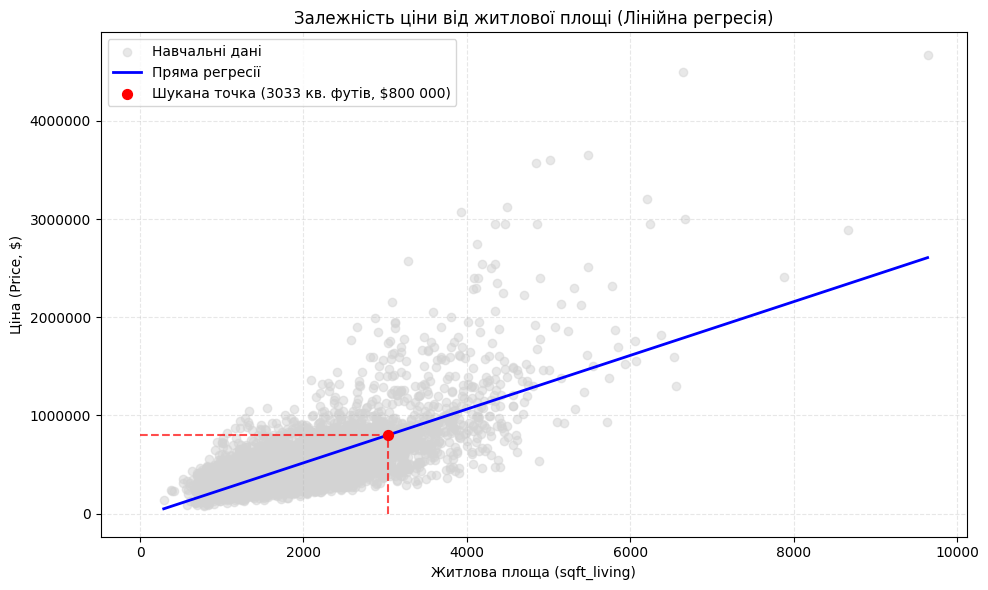

In [41]:
estimated_sqft = inverse_regression_predictions(800000, sqft_intercept, sqft_slope)
print(estimated_sqft)

plt.figure(figsize=(10, 6))

plt.scatter(train_data['sqft_living'], train_data['price'], 
            color='lightgray', alpha=0.5, label='Навчальні дані')

x_line = np.array([train_data['sqft_living'].min(), train_data['sqft_living'].max()])
y_line = sqft_intercept + sqft_slope * x_line
plt.plot(x_line, y_line, color='blue', linewidth=2, label='Пряма регресії')

plt.scatter(estimated_sqft, 800000, color='red', s=50, zorder=5, 
            label=f'Шукана точка ({estimated_sqft:.0f} кв. футів, $800 000)')


plt.vlines(x=estimated_sqft, ymin=0, ymax=800000, color='red', linestyle='--', alpha=0.7)
plt.hlines(y=800000, xmin=0, xmax=estimated_sqft, color='red', linestyle='--', alpha=0.7)

plt.title('Залежність ціни від житлової площі (Лінійна регресія)')
plt.xlabel('Житлова площа (sqft_living)')
plt.ylabel('Ціна (Price, $)')
plt.legend()

plt.ticklabel_format(style='plain', axis='both')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()